In [3]:
import numpy as np
import pint

from jablonski import (
    Simulator,
    SingletState,
    SpectroscopicSystem,
    TripletState,
    initial,
)
from jablonski.simulation import (
    delta_excitation,
    piecewise,
    pulse_excitation,
    spectral_time_resolved_emission,
)
from jablonski.transitions import (
    Absorption,
    Fluorescence,
    IntersystemCrossing,
    Phosphorescence,
)

u = pint.get_application_registry()


class Model(SpectroscopicSystem):
    # Define states with energies, mid is a triplet state
    low: SingletState = initial(0 * u.eV, "singlet", default=100)
    mid: TripletState = initial(2 * u.eV, "triplet", default=0)
    high: SingletState = initial(3 * u.eV, "singlet", default=0)

    # Define absorptions and emissions
    absorption_1 = Absorption(ground=low, excited=high, rate=1e-15 * u.cm**2)
    emission_1 = Phosphorescence(ground=low, excited=mid, rate=2e8 / u.s)
    emission_2 = IntersystemCrossing(source=high, target=mid, rate=0.5e8 / u.s)
    emission_3 = Fluorescence(ground=low, excited=high, rate=1e8 / u.s)


sim = Simulator(Model)

<Axes: xlabel='time'>

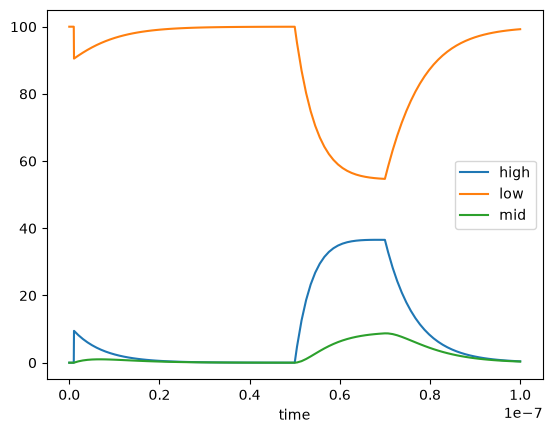

In [34]:
# Picewise simulation with a delta excitation at t = 0 and a pulse between t = 5 and t = 7
delta = delta_excitation(
    Model.absorption_1, start=0.1e-8 * u.s, area=1e14 / u.cm**2
)  # delta excitiation
pulse = pulse_excitation(
    {Model.absorption_1:1e23 / (u.cm**2 * u.s)}, start=5e-8*u.s, width=2e-8*u.s
)  # delta excitiation
result_1 = piecewise(sim, events=delta | pulse, save_at=np.linspace(0, 100, 100)*u.ns)
result_1.pint.dequantify().to_dataframe().plot()

In [5]:
result_1

Magnitude,[0.0 1e-09 1.0101010101010101e-09 1.05e-09 2.0202020202020203e-09 3.0303030303030304e-09 4.0404040404040405e-09 5.050505050505051e-09 6.060606060606061e-09 7.070707070707071e-09 8.080808080808081e-09 9.090909090909092e-09 1.0101010101010102e-08 1.1111111111111114e-08 1.2121212121212122e-08 1.3131313131313133e-08 1.4141414141414143e-08 1.5151515151515152e-08 1.6161616161616162e-08 1.7171717171717175e-08 1.8181818181818185e-08 1.9191919191919195e-08 2.0202020202020204e-08 2.1212121212121217e-08 2.2222222222222227e-08 2.3232323232323237e-08 2.4242424242424243e-08 2.5252525252525253e-08 2.6262626262626266e-08 2.7272727272727276e-08 2.8282828282828285e-08 2.9292929292929295e-08 3.0303030303030305e-08 3.1313131313131315e-08 3.2323232323232324e-08 3.333333333333334e-08 3.434343434343435e-08 3.535353535353536e-08 3.636363636363637e-08 3.737373737373738e-08 3.838383838383839e-08 3.93939393939394e-08 4.040404040404041e-08 4.141414141414142e-08 4.2424242424242435e-08 4.3434343434343444e-08 4.4444444444444454e-08 4.5454545454545464e-08 4.6464646464646474e-08 4.7474747474747483e-08 4.8484848484848486e-08 4.9494949494949496e-08 5e-08 5.0505050505050506e-08 5.1515151515151516e-08 5.252525252525253e-08 5.353535353535354e-08 5.454545454545455e-08 5.555555555555556e-08 5.656565656565657e-08 5.757575757575758e-08 5.858585858585859e-08 5.95959595959596e-08 6.060606060606061e-08 6.161616161616163e-08 6.262626262626263e-08 6.363636363636365e-08 6.464646464646465e-08 6.565656565656566e-08 6.666666666666668e-08 6.767676767676768e-08 6.86868686868687e-08 6.96969696969697e-08 6.999999999999999e-08 7.070707070707072e-08 7.171717171717172e-08 7.272727272727274e-08 7.373737373737374e-08 7.474747474747476e-08 7.575757575757578e-08 7.676767676767678e-08 7.77777777777778e-08 7.87878787878788e-08 7.979797979797981e-08 8.080808080808082e-08 8.181818181818183e-08 8.282828282828284e-08 8.383838383838385e-08 8.484848484848487e-08 8.585858585858587e-08 8.686868686868689e-08 8.787878787878789e-08 8.888888888888891e-08 8.989898989898991e-08 9.090909090909093e-08 9.191919191919193e-08 9.292929292929295e-08 9.393939393939396e-08 9.494949494949497e-08 9.595959595959598e-08 9.696969696969697e-08 9.797979797979799e-08 9.898989898989899e-08 1.0000000000000001e-07]
Units,second


line_emission_1: 2 electron_volt
line_emission_3: 3 electron_volt


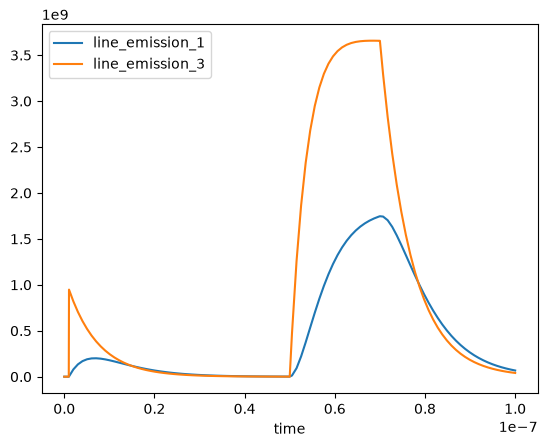

In [6]:
# spectral time resolved emission for same excitation
result_2 = spectral_time_resolved_emission(
    sim, excitation=delta | pulse, save_at=np.linspace(0, 100, 100) *  u.ns
)
result_2.pint.dequantify().to_dataframe().plot()

# We can see each lines energy in the Datasets attributes
for line, energy in result_2.attrs.items():
    print(f"{line}: {energy}")

<Axes: xlabel='time'>

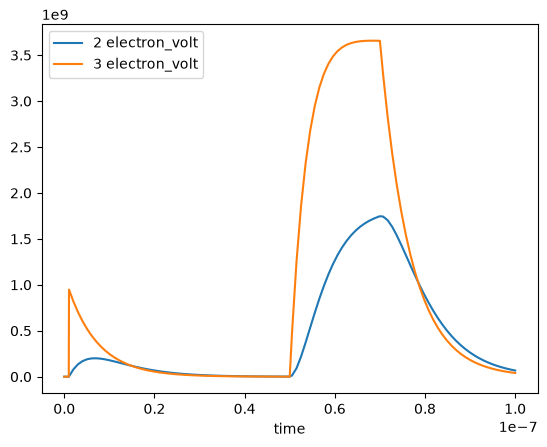

In [7]:
# join_by_energy groups lines of the same energy and outputs energy instead of name
result_2 = spectral_time_resolved_emission(
    sim,
    excitation=delta | pulse,
    save_at=np.linspace(0, 100, 100) * u.ns ,
    join_by_energy=True,
)
result_2.pint.dequantify().to_dataframe().plot()

<Axes: xlabel='time'>

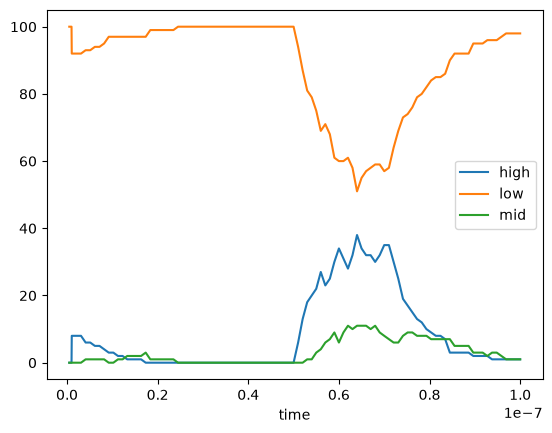

In [32]:
# Stochastic simulation
from jablonski.rebop import RebopSimulator, rebop_piecewise

rsim = RebopSimulator(Model)
rebop_result = rebop_piecewise(rsim, events= pulse | delta, upto_t=100 * u.ns, n_points=100)
rebop_result.to_dataframe().plot()

<Axes: xlabel='time'>

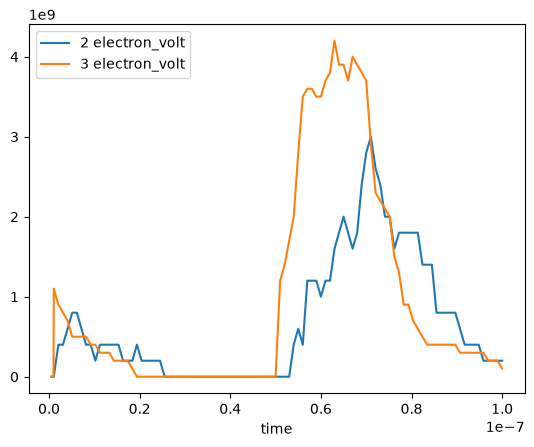

In [29]:
# Spectral time resolved emission
from jablonski.rebop.rebop import rebop_spectral_time_resolved_emission
import matplotlib.pyplot as plt

rebop_result = rebop_spectral_time_resolved_emission(rsim, excitation= pulse | delta, upto_t=100 * u.ns, n_points=100, join_by_energy=True)
rebop_result.pint.dequantify().to_dataframe().plot()